In [1]:
import os
from pathlib import Path

import pandas as pd

parent_dir = Path().cwd().parent
os.chdir(parent_dir)

from src.data_pipeline.loader import DataPreparer
from src.data_pipeline.pipeline_models import data_pipeline_settings

In [2]:
loader = DataPreparer(data_pipeline_settings)

df = loader.prepare_data()

In [7]:
df

,date,T1,P2,F3,P4,F5,T6_x,F7,F8,F9_x,...,F19_y,Q20,Q21,F22,T23,P24,F25_y,F26_y,24-2000:Mg.Sulfur,24-2000:D15
0,2023-01-01 00:00:00,130.372528,3.540594,68.645889,3.848177,103.866081,234.733780,217.544907,211.697418,195.954498,...,167.797852,7143.850098,7.699553,10507.554688,234.196854,0.594864,13242.359375,201.230698,6.572924,NaN
1,2023-01-01 00:10:00,130.312668,3.535826,68.768883,3.847023,103.823425,234.711334,217.332169,211.644348,195.884033,...,168.481689,7596.144531,6.959560,10526.750000,233.974182,0.595058,13214.491211,201.488571,6.730094,NaN
2,2023-01-01 00:20:00,130.254074,3.532611,68.994743,3.844830,98.811737,234.677292,217.119431,211.591278,195.813583,...,167.650955,7656.547363,6.510911,11271.607422,233.929260,0.592871,13313.846680,201.574692,7.158879,NaN
3,2023-01-01 00:30:00,130.195465,3.532775,68.718155,3.841944,97.248512,234.480499,216.560745,211.538208,195.552078,...,166.420822,7939.474121,5.955529,12260.086914,234.033798,0.595605,13290.474609,201.460220,7.620472,NaN
4,2023-01-01 00:40:00,130.131912,3.532940,68.386543,3.839058,103.873940,234.283707,215.707336,211.450958,195.234589,...,166.531998,8020.019531,5.592346,13249.763672,233.899139,0.595312,13065.634766,203.041473,8.173620,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181152,2026-08-06 23:20:00,131.194336,3.836440,107.416397,4.161318,439.080719,229.764740,291.509308,279.740143,355.167694,...,238.619781,7662.971680,7.985026,8585.574219,232.503662,0.579832,13531.119141,296.155029,8.007294,835.1230
181153,2026-08-06 23:30:00,131.336182,3.837928,107.527336,4.162167,425.742493,229.890030,291.837250,279.604156,355.313599,...,240.845184,7640.085938,7.559968,8608.854492,232.568710,0.576999,13404.511719,297.104767,7.706686,835.4171
181154,2026-08-06 23:40:00,131.114349,3.839417,107.628471,4.163015,438.722351,230.018845,292.066010,278.693268,355.031616,...,244.287338,7656.569824,7.293701,8598.671875,232.635071,0.574730,13146.961914,297.935822,7.392977,835.5061
181155,2026-08-06 23:50:00,131.180481,3.837819,107.398705,4.160222,425.805847,230.147659,292.128174,277.782410,354.749634,...,252.587006,7431.098633,7.429495,8613.925781,232.707993,0.573450,13283.888672,298.311127,7.394635,835.6401


In [8]:
df_avt = pd.read_csv("data/raw/avt_tags.csv", engine='pyarrow')
df_242000 = pd.read_csv("data/raw/242000_tags.csv", engine='pyarrow')

In [9]:
print((df['Unnamed: 0.1'] == df['Unnamed: 0']).all())
print((df['Unnamed: 0.1'] == df.index.to_series()).all())
print((df['Unnamed: 0.1'] == df.iloc[:, 74]).all())

KeyError: 'Unnamed: 0.1'

столбцы полностью одинаквые, поэтому можем их удалить

In [3]:
#df = loader.clean_data(df)
df.info()

<class 'pandas.DataFrame'>
Index: 181157 entries, 0 to 189216
Data columns (total 98 columns):
 #   Column  Non-Null Count   Dtype        
---  ------  --------------   -----        
 0   date    181157 non-null  datetime64[s]
 1   T1      181157 non-null  float64      
 2   P2      181157 non-null  float64      
 3   F3      181157 non-null  float64      
 4   P4      181157 non-null  float64      
 5   F5      181157 non-null  float64      
 6   T6_x    181157 non-null  float64      
 7   F7      181157 non-null  float64      
 8   F8      181157 non-null  float64      
 9   F9_x    181157 non-null  float64      
 10  D10     181157 non-null  int64        
 11  T11_x   181157 non-null  float64      
 12  F12     181157 non-null  float64      
 13  T13     181157 non-null  float64      
 14  F14_x   181157 non-null  float64      
 15  T15     181157 non-null  float64      
 16  F16     181157 non-null  float64      
 17  T17     181157 non-null  float64      
 18  T18_x   181157 non-n

## Периоды простоя

Попробуем найти периоды когда аномалии были одновременно на большом колчестве датчиков, предположительно такие проблемы могут быть вызваны сбоями инфраструктуры(информаци не поступает нормально, перебои с питанием и ТД.)

In [5]:
def robust_z(s):
    med, mad = s.median(), (s - s.median()).abs().median()
    return (s - med) / (1.4826 * mad + 1e-9)

cont_cols = df.drop(columns=["date"]).columns #только столбцы с тэгами
z = df[cont_cols].apply(robust_z)
downtime_score = (z.abs() > 5).mean(axis=1)   # проверяет отклоняется ли z-score более чем на 5 стандартных отклонений и считает долю датчиков с таким отклонением с в строке
#df['is_downtime'] = downtime_score > 0.3      # проверка на порог(от какой доли датчиков считаем даунтаймом)

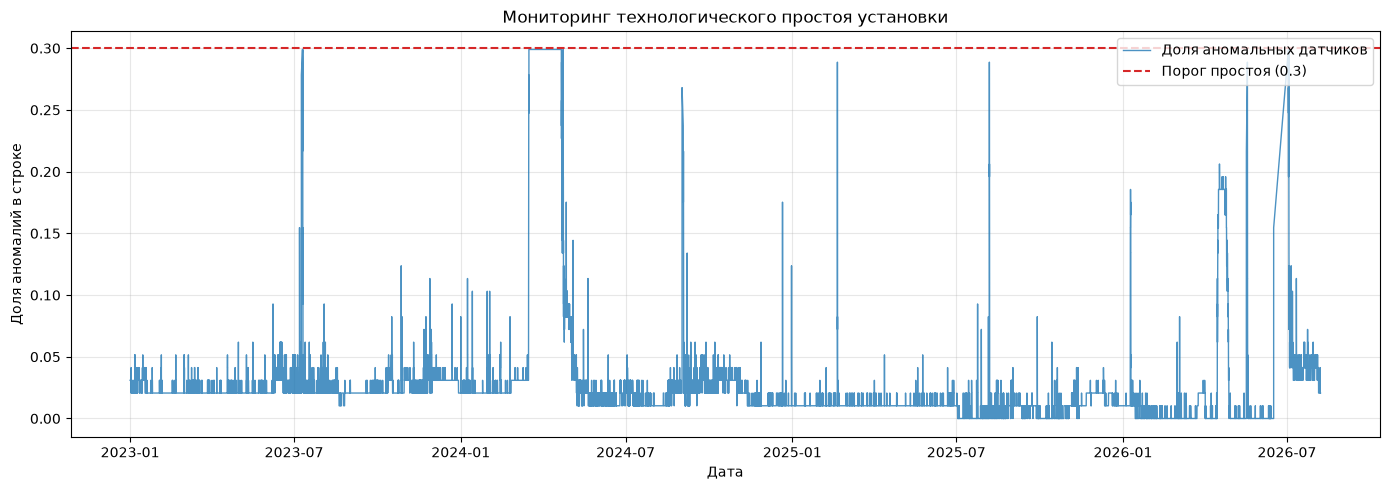

In [6]:
import matplotlib.pyplot as plt

# Убедимся, что колонка сохранена в датафрейме
df['downtime_score'] = downtime_score

plt.figure(figsize=(14, 5))

# 1. Линия общего индекса простоя во времени
plt.plot(df['date'], df['downtime_score'], label='Доля аномальных датчиков', color='tab:blue', alpha=0.8, linewidth=1)

# 2. Линия порога
plt.axhline(y=0.3, color='tab:red', linestyle='--', label='Порог простоя (0.3)', linewidth=1.5)

# 3. Подсветка точек, где сработал флаг простоя
#downtime_points = df[df['is_downtime']]
#plt.scatter(downtime_points['date'], downtime_points['downtime_score'], color='tab:red', s=12, label='Моменты простоя', zorder=5)

plt.xlabel('Дата')
plt.ylabel('Доля аномалий в строке')
plt.title('Мониторинг технологического простоя установки')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
corr = df.loc[~df['is_downtime'], cont_cols].corr().abs()

KeyError: 'is_downtime'

In [ ]:
import numpy as np

upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
pairs = upper.stack().sort_values(ascending=False)
suspects = pairs[pairs > 0.98]
print(suspects)

F9_y  F26_y    0.999912
P23   P67      0.999469
F56   F57      0.999316
T6_y  T11_y    0.997793
F59   F60      0.997365
T5    T6_y     0.995576
      T11_y    0.995363
F30   W70      0.987665
F17   F19_y    0.981300
dtype: float64


<Axes: xlabel='date'>

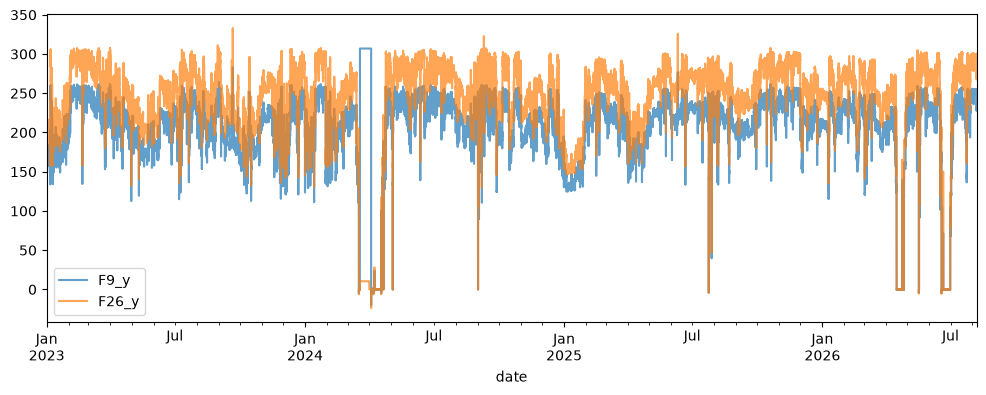

In [ ]:
df.set_index('date')[['F9_y', 'F26_y']].plot(figsize=(12,4), alpha=0.7)

In [ ]:
row = df.iloc[0].index
row[row != "date"]

Index(['T1', 'P2', 'F3', 'P4', 'F5', 'T6_x', 'F7', 'F8', 'F9_x', 'D10',
       'T11_x', 'F12', 'T13', 'F14_x', 'T15', 'F16', 'T17', 'T18_x', 'F19_x',
       'T20', 'P21', 'P22', 'P23', 'T24', 'F25_x', 'F26_x', 'F27', 'F28',
       'F29', 'F30', 'F31', 'F32', 'T33', 'F34', 'F35', 'F36', 'T37', 'T38',
       'T39', 'T40', 'F41', 'T42', 'L43', 'P44', 'F45', 'F46', 'T47', 'T48',
       'T49', 'P50', 'P51', 'P52', 'F53', 'F54', 'T55', 'F56', 'F57', 'T58',
       'F59', 'F60', 'T61', 'F62', 'F63', 'F64', 'F65', 'T66', 'P67', 'F68',
       'F69', 'W70', 'T71', 'F1', 'F2', 'P3', 'W4', 'T5', 'T6_y', 'W7', 'P8',
       'F9_y', 'W10', 'T11_y', 'T12', 'P13', 'F14_y', 'F15', 'T16', 'F17',
       'T18_y', 'F19_y', 'Q20', 'Q21', 'F22', 'T23', 'P24', 'F25_y', 'F26_y',
       'is_downtime', 'downtime_score'],
      dtype='str')

In [3]:
df = loader.prepare_data()

In [4]:
df

,date,T1,P2,F3,P4,F5,T6_x,F7,F8,F9_x,...,F17,T18_y,F19_y,Q20,Q21,F22,T23,P24,F25_y,F26_y
0,2023-01-01 00:00:00,130.372528,3.540594,68.645889,3.848177,103.866081,234.733780,217.544907,211.697418,195.954498,...,208.366318,66.580772,167.797852,7143.850098,7.699553,10507.554688,234.196854,0.594864,13242.359375,201.230698
1,2023-01-01 00:10:00,130.312668,3.535826,68.768883,3.847023,103.823425,234.711334,217.332169,211.644348,195.884033,...,206.546371,66.387772,168.481689,7596.144531,6.959560,10526.750000,233.974182,0.595058,13214.491211,201.488571
2,2023-01-01 00:20:00,130.254074,3.532611,68.994743,3.844830,98.811737,234.677292,217.119431,211.591278,195.813583,...,204.726425,66.762436,167.650955,7656.547363,6.510911,11271.607422,233.929260,0.592871,13313.846680,201.574692
3,2023-01-01 00:30:00,130.195465,3.532775,68.718155,3.841944,97.248512,234.480499,216.560745,211.538208,195.552078,...,205.050873,67.137100,166.420822,7939.474121,5.955529,12260.086914,234.033798,0.595605,13290.474609,201.460220
4,2023-01-01 00:40:00,130.131912,3.532940,68.386543,3.839058,103.873940,234.283707,215.707336,211.450958,195.234589,...,206.608307,67.722862,166.531998,8020.019531,5.592346,13249.763672,233.899139,0.595312,13065.634766,203.041473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189212,2026-08-06 23:20:00,131.194336,3.836440,107.416397,4.161318,439.080719,229.764740,291.509308,279.740143,355.167694,...,304.541504,65.573502,238.619781,7662.971680,7.985026,8585.574219,232.503662,0.579832,13531.119141,296.155029
189213,2026-08-06 23:30:00,131.336182,3.837928,107.527336,4.162167,425.742493,229.890030,291.837250,279.604156,355.313599,...,303.739502,65.747917,240.845184,7640.085938,7.559968,8608.854492,232.568710,0.576999,13404.511719,297.104767
189214,2026-08-06 23:40:00,131.114349,3.839417,107.628471,4.163015,438.722351,230.018845,292.066010,278.693268,355.031616,...,301.167603,65.970657,244.287338,7656.569824,7.293701,8598.671875,232.635071,0.574730,13146.961914,297.935822
189215,2026-08-06 23:50:00,131.180481,3.837819,107.398705,4.160222,425.805847,230.147659,292.128174,277.782410,354.749634,...,300.048645,65.992149,252.587006,7431.098633,7.429495,8613.925781,232.707993,0.573450,13283.888672,298.311127


# 